# Financial Time Series Data

## Introduction

Welcome to **Project 8** — the capstone of the course. Here we tackle a
kind of data with a personality of its own: **financial price series**.

> ❓ A stock's average daily return is tiny and almost unpredictable — so
> what is there to model? The answer is **risk itself**: how violently
> returns swing around that average, and *how that violence changes over
> time*.

In earlier projects you worked with cross-sectional data (housing prices,
earthquake damage) and with regular time series (air-quality readings).
Financial markets add a new twist: even after removing any trend, the
**variability** of returns is not constant — calm stretches and stormy
stretches come in runs. This first notebook lays the groundwork for the
**GARCH volatility models** you will build in Lesson 3.

🎯 **By the end of this notebook you will be able to:**

-   Understand how financial data flows from a web API to a local CSV
    file.
-   Load financial time series data from CSV files into pandas
    DataFrames.
-   Compute simple and logarithmic returns from price series.
-   Visualize return series and identify volatility clustering.
-   Explain why constant-variance models are insufficient for financial
    data.
-   Prepare a clean return series suitable for volatility modeling.

➡️ First, watch the short walkthrough video, then we will build the data
pipeline from the API call down to a clean return series.

In [ ]:
from IPython.display import VimeoVideo

# Bigger video
VimeoVideo("1183285512", h="3298dbabb7", width=700, height=450) 

# 1. Conceptual Foundation

## From APIs to CSV files: where the data comes from

In previous projects you loaded data from CSV files, MongoDB, and SQL
databases. In production, financial data is most often fetched from **web
APIs** — services that return structured data (usually JSON) in response
to an HTTP request.

> 💡 The API-to-CSV pipeline (three moves)

1.  **Request** — send an HTTP request to an API endpoint with
    parameters (ticker symbol, output size, API key).
2.  **Receive** — the server responds with data in **JSON** format.
3.  **Persist** — parse the JSON into a pandas DataFrame and save it as a
    **CSV** for reproducible analysis.

We will walk through this end-to-end with a hands-on demo. So the notebook
never depends on a live internet connection, a helper module called
`mock_alpha` intercepts the HTTP call and returns a realistic sample
payload. **The code you write is identical to a real API call — only the
network layer is simulated.**

> 📌 How the mock works
>
> `mock_alpha` uses `unittest.mock` internally to intercept
> `requests.get` and return the contents of
> `data/alpha_ambujacem_bse_full.json` — a real AlphaVantage response
> saved to disk. No network request is made. In a real project you would
> drop the mock and supply a valid API key.

First, activate the mock so that `requests.get` returns the local JSON
data:

In [1]:
import requests
import pandas as pd
from mock_alpha import activate_mock, deactivate_mock

# Start intercepting requests.get
activate_mock()

Now build the URL and make the request exactly as you would against the
real API. The `outputsize` parameter controls how much data you get
back:

| `outputsize` | What you get | When to use |
|---|---|---|
| `"compact"` | the latest **100** observations | quick checks, demos |
| `"full"` | the **entire** available history | real modeling |

Let's start with `"compact"`:

In [2]:
# Build the URL with query parameters
ticker = "AMBUJACEM.BSE"
output_size = "compact"
url = (
    "https://www.alphavantage.co/query?"
    "function=TIME_SERIES_DAILY&"
    f"symbol={ticker}&"
    f"outputsize={output_size}&"
    "datatype=json&"
    "apikey=demo"  # in a real project, you would use your own API key
)

# Send the GET request (intercepted by the mock)
response = requests.get(url)
print("Status code:", response.status_code)

data = response.json()
n_days = len(data["Time Series (Daily)"])
print(f"outputsize='{output_size}' returned {n_days} days")
assert n_days == 100

Status code: 200
outputsize='compact' returned 100 days


> 🔍 What to notice
>
> The status code should be `200` (success) and the response should carry
> exactly **100** days — that is what the `assert n_days == 100` line
> guards. Now switch to `"full"` to see the whole history:

In [3]:
output_size = "full"
url = (
    "https://www.alphavantage.co/query?"
    "function=TIME_SERIES_DAILY&"
    f"symbol={ticker}&"
    f"outputsize={output_size}&"
    "datatype=json&"
    "apikey=demo"
)

response = requests.get(url)
data = response.json()
n_days = len(data["Time Series (Daily)"])
print(f"outputsize='{output_size}' returned {n_days} days")
assert n_days > 2000

outputsize='full' returned 5225 days


📊 Now `outputsize="full"` returns **thousands** of days instead of 100 —
the `assert n_days > 2000` confirms we have a long history, which is what
volatility modeling needs (you cannot characterize rare turbulent
episodes from only 100 days).

The `response` object behaves exactly like a real one. Let's extract and
clean the data:

In [4]:
# Parse JSON into a dictionary
data = response.json()

# Extract the time series portion
stock_data = data["Time Series (Daily)"]

# Convert to DataFrame (values arrive as strings)
df = pd.DataFrame.from_dict(
    stock_data, orient="index", dtype=float
)

# Fix the index: convert to DatetimeIndex, name it
df.index = pd.to_datetime(df.index)
df.index.name = "date"

# Clean column names: "1. open" -> "open"
df.columns = [c.split(". ")[1] for c in df.columns]

# Sort chronologically (API returns newest first)
df.sort_index(inplace=True)

print(df.dtypes)
df

open      float64
high      float64
low       float64
close     float64
volume    float64
dtype: object


,open,high,low,close,volume
date,,,,,
2005-01-03,405.0001,409.5001,403.1001,407.6001,1061050.0
2005-01-04,410.0001,429.0001,409.0001,425.8501,2501549.0
2005-01-05,427.0001,439.9001,406.1501,425.9501,3537669.0
2005-01-06,426.0001,431.0001,412.0001,416.0501,3103853.0
2005-01-07,420.0001,428.5001,418.0001,426.3001,2330736.0
...,...,...,...,...,...
2026-03-16,425.1000,435.0000,424.8000,428.3500,155843.0
2026-03-17,430.8000,436.2000,428.1000,433.9500,253700.0
2026-03-18,438.4500,444.0000,433.9000,441.1500,60332.0


> 📊 What that cleaning step did
>
> - **Parsed** the JSON into a dictionary and pulled out the
>   `"Time Series (Daily)"` block.
> - **Converted** the nested dict into a DataFrame, coercing the
>   string values to `float`.
> - **Fixed the index**: turned the date strings into a `DatetimeIndex`
>   named `date`.
> - **Renamed** columns (`"1. open"` → `"open"`) and **sorted**
>   chronologically (the API returns newest-first).
>
> ⚠️ Raw API payloads almost always need this cleanup — values arrive as
> strings, dates as text, and rows in reverse order.

Finally, save the cleaned DataFrame to a CSV file. This is the step that
**decouples your analysis from the external service**:

In [5]:
# Save to CSV so downstream notebooks work from
# a flat file instead of the API
df.to_csv("data/ambuja_cement.csv")
print("Saved to data/ambuja_cement.csv. Shape:", df.shape)

Saved to data/ambuja_cement.csv. Shape: (5225, 5)


With the data safely on disk, switch the mock back off so `requests`
behaves normally for the rest of your environment:

In [6]:
# Deactivate the mock — restore normal requests behavior
deactivate_mock()

> 📌 Key ideas to take away
>
> - An **API** (Application Programming Interface) lets programs request
>   data from a server via a URL with parameters — much like passing
>   arguments to a Python function.
> - `requests.get(url)` sends an HTTP request; `response.json()` converts
>   the JSON text into a Python dictionary.
> - API responses usually need cleaning: strings → numeric types, fixing
>   the index, renaming columns, sorting.
> - Once the data is a DataFrame, saving it as CSV decouples your
>   analysis from the external service — exactly what was done to prepare
>   this project's files.

For the rest of this notebook (and the whole project) you will work
**exclusively with the pre-downloaded CSV files**, guaranteeing
reproducibility and no dependency on external services.

➡️ Before we touch the data, let's frame what the whole project is
building toward.

## Project context: what we're trying to build

This capstone builds an **end-to-end system that models and forecasts
volatility** — the degree of variation in an asset's returns over time.
Accurate volatility forecasts drive **risk management, option pricing,
and portfolio construction**.

> 🧱 The project spans four notebooks

1.  **Lesson 1 (this notebook):** fetch price data from an API, save it
    locally, compute returns, and explore stylized facts.
2.  **Lesson 2:** apply **test-driven development** to validate the data
    pipeline and package it into reusable classes.
3.  **Lesson 3:** fit **GARCH models** to capture time-varying
    volatility.
4.  **Lesson 4:** **package and deploy** the model as a prediction
    service behind a web API.

In the conceptual section you saw the full API-to-CSV pipeline; in the
exercises you work with the resulting CSV so results are reproducible.

➡️ The first transformation every financial analysis makes is **prices →
returns**. Here is why, and how.

## Price series, returns, and why returns matter

❗️ **But wait — why not model prices directly?** Raw price series are
**non-stationary**: they drift up or down and wander without a stable
mean or variance. Models that assume a stable distribution choke on this.
The standard fix in finance is to work with **returns** instead of
prices.

There are two common definitions. Given a price series $P_t$:

> 🧮 **Simple return**

$$
R_t = \frac{P_t - P_{t-1}}{P_{t-1}}
$$

> 🧮 **Logarithmic (log) return**

$$
r_t = \ln\!\left(\frac{P_t}{P_{t-1}}\right) = \ln P_t - \ln P_{t-1}
$$

where $P_t$ is the price on day $t$ and $P_{t-1}$ the price the day
before.

**Why prefer log returns?** They are **time-additive**: the cumulative
log return over $n$ days is simply the *sum* of the daily log returns,

$$
r_{t_1 \to t_n} = \sum_{k=1}^{n} r_k = \ln\!\left(\frac{P_{t_n}}{P_{t_0}}\right)
$$

so aggregating across time is just addition. They are also more symmetric
(a +10% move and a −10% move have equal-magnitude log returns). That
makes them the default for many time-series models, GARCH included.

| | Simple return $R_t$ | Log return $r_t$ |
|---|---|---|
| Formula | $(P_t-P_{t-1})/P_{t-1}$ | $\ln(P_t/P_{t-1})$ |
| Aggregating over time | multiply $(1+R)$ factors | **add** them |
| Symmetry of ±moves | asymmetric | symmetric |
| Small daily moves | ≈ identical | ≈ identical |

> 📌 For the small daily moves typical of equities, $R_t \approx r_t$ —
> the two definitions nearly coincide. They diverge for large moves.

Let's compute both on a tiny example:

In [7]:
import numpy as np
import pandas as pd

# Toy price series: 5 days of closing prices
prices = pd.Series(
    [100.0, 102.0, 99.0, 101.5, 103.0],
    index=pd.date_range("2025-01-06", periods=5, freq="B"),
    name="close",
)
prices.index.name = "date"
print("Price series:")
print(prices)

Price series:
date
2025-01-06    100.0
2025-01-07    102.0
2025-01-08     99.0
2025-01-09    101.5
2025-01-10    103.0
Freq: B, Name: close, dtype: float64


**Code 8.1.0 demo — simple returns** with `pct_change`:

In [8]:
# Simple returns using pct_change
simple_returns = prices.pct_change()
print("Simple returns:")
print(simple_returns)

Simple returns:
date
2025-01-06         NaN
2025-01-07    0.020000
2025-01-08   -0.029412
2025-01-09    0.025253
2025-01-10    0.014778
Freq: B, Name: close, dtype: float64


And the **log returns** with `numpy`:

In [9]:
# Log returns using numpy
log_returns = np.log(prices / prices.shift(1))
print("Log returns:")
print(log_returns)

Log returns:
date
2025-01-06         NaN
2025-01-07    0.019803
2025-01-08   -0.029853
2025-01-09    0.024939
2025-01-10    0.014670
Freq: B, Name: close, dtype: float64


> 🔍 What to notice
>
> - The **first value is `NaN`** in both series — there is no prior price
>   to compare day 0 against. You must `dropna()` before modeling.
> - The simple and log returns are **nearly identical** here because the
>   daily moves are small — exactly as the table above predicted. They
>   would diverge more for large jumps.

➡️ Returns are the raw material. The single most important *property* of
financial returns is how their spread changes over time — **volatility
clustering**.

## Volatility clustering: the key stylized fact

Financial return series show a famous pattern called **volatility
clustering**: large moves (up or down) tend to be followed by more large
moves, and calm periods tend to persist. *Calm follows calm; storms
follow storms.*

> 🧮 **Volatility** is the standard deviation of returns

$$
\sigma = \sqrt{\frac{1}{N-1}\sum_{t=1}^{N}\left(r_t - \bar{r}\right)^2}
$$

where $\bar{r}$ is the mean return and $N$ the number of observations.
A *single* $\sigma$ summarizes the whole series — but clustering says that
is misleading, because the spread is not constant.

> 🧠 Stated precisely
>
> Returns $r_t$ are themselves almost **uncorrelated** across time (you
> can't predict tomorrow's direction). But their **magnitudes** $|r_t|$
> (and squares $r_t^2$) **are autocorrelated** — today being turbulent
> makes tomorrow more likely to be turbulent. So the *variance* changes
> over time.

This violates a core assumption of ordinary linear regression: constant
variance, or **homoskedasticity**. Models like **GARCH** are built
specifically to capture this **conditional heteroskedasticity** —
variance that depends on recent history. That is the whole point of
Lesson 3.

Let's make the idea visible with a small synthetic example:

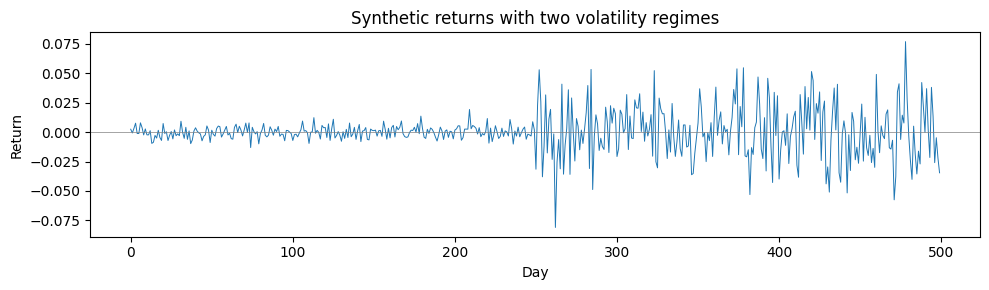

In [10]:
import matplotlib.pyplot as plt

np.random.seed(42)
n = 500

# Simulate two regimes: low-vol and high-vol
low_vol = np.random.normal(0, 0.005, n // 2)
high_vol = np.random.normal(0, 0.025, n // 2)
synthetic_returns = np.concatenate([low_vol, high_vol])

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(synthetic_returns, linewidth=0.7)
ax.set_title("Synthetic returns with two volatility regimes")
ax.set_xlabel("Day")
ax.set_ylabel("Return")
ax.axhline(0, color="gray", linewidth=0.5)
plt.tight_layout()
plt.show()

> 📊 Interpretation
>
> The first half of the series is **calm** (small wiggles) and the second
> half is **turbulent** (wide swings) — two clearly different variance
> regimes. Real markets show the same clustering, except the transitions
> happen **organically** rather than at one sharp cutoff. This visual is
> the entire motivation for a model whose variance is allowed to move.

➡️ The project data lives in CSV files, so next we make sure we can load
them cleanly.

## Loading CSV data with pandas

The project data is stored in CSV files, so you need to load them with
the right options. The three most common pitfalls:

> ⚠️ CSV loading pitfalls
>
> - **Wrong delimiter or encoding** — inspect the first few lines if
>   `read_csv` produces surprises.
> - **Date parsing** — pass `parse_dates=["date"]`, or set the date as
>   the index with `index_col` + `parse_dates=True`.
> - **Dtype issues** — numeric columns can load as strings if they
>   contain commas, currency symbols, or missing-value placeholders.

Here is a quick demonstration with a tiny in-memory CSV:

In [11]:
from io import StringIO

csv_text = """\
date,close,volume
2025-01-06,100.00,1500000
2025-01-07,102.00,1600000
2025-01-08,99.00,1750000
"""

df_demo = pd.read_csv(
    StringIO(csv_text),
    parse_dates=["date"],
    index_col="date",
)
print(df_demo.dtypes)
df_demo

close     float64
volume      int64
dtype: object


,close,volume
date,,
2025-01-06,100.0,1500000
2025-01-07,102.0,1600000
2025-01-08,99.0,1750000


> 📌 In real use you replace `StringIO(csv_text)` with a file path such
> as `"data/ambuja_cement.csv"`. The dtypes printed above should be
> numeric and the index a `DatetimeIndex`.

➡️ Loading is only half the job — always validate what you loaded.

## Inspecting and validating a DataFrame

After loading, always run a quick health check before trusting the data:

In [12]:
# Shape, dtypes, and missing values in one glance
print("Shape:", df_demo.shape)
print()
df_demo.info()

Shape: (3, 2)

<class 'pandas.DataFrame'>
DatetimeIndex: 3 entries, 2025-01-06 to 2025-01-08
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   close   3 non-null      float64
 1   volume  3 non-null      int64  
dtypes: float64(1), int64(1)
memory usage: 72.0 bytes


And the numeric summary:

In [13]:
# Summary statistics for numeric columns
df_demo.describe()

,close,volume
count,3.000000,3.000000e+00
mean,100.333333,1.616667e+06
std,1.527525,1.258306e+05
min,99.000000,1.500000e+06
25%,99.500000,1.550000e+06
50%,100.000000,1.600000e+06
75%,101.000000,1.675000e+06
max,102.000000,1.750000e+06


> 🔍 What to look for
>
> - Unexpected **`object` dtypes** (a parsing problem in disguise).
> - **`NaN` counts** — where, and how many.
> - **Unreasonable min/max** values (a stray spike or a zero price).

➡️ With clean data in hand, the fastest way to *see* its structure is to
plot price and returns together.

## Visualizing price and return series

Two plots form the backbone of any first look at financial data:

1.  **Price chart** — the overall trend and any obvious anomalies.
2.  **Return chart** — the volatility structure that prices alone hide.

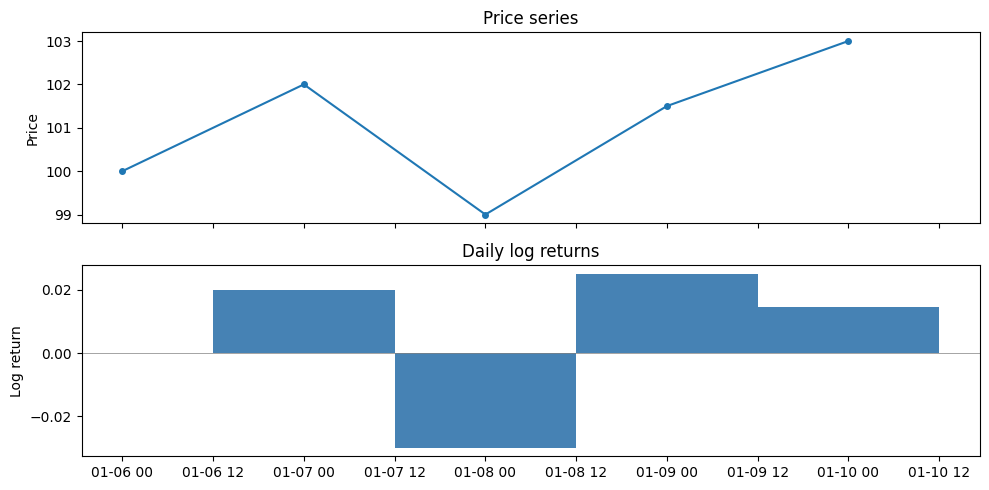

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)

# Price chart
axes[0].plot(prices, marker="o", markersize=4)
axes[0].set_ylabel("Price")
axes[0].set_title("Price series")

# Return chart (log returns)
axes[1].bar(
    log_returns.dropna().index,
    log_returns.dropna().values,
    width=1,
    color="steelblue",
)
axes[1].set_ylabel("Log return")
axes[1].set_title("Daily log returns")
axes[1].axhline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

> 📊 What the two panels tell you
>
> - The **top (price)** panel shows the level and trend — useful for
>   spotting gaps or impossible jumps.
> - The **bottom (returns)** panel is where **volatility clustering**
>   appears: stretches of tall bars vs. stretches of short bars.
>
> With only five points the pattern is invisible; with hundreds or
> thousands of observations the alternating calm/turbulent runs jump out.

➡️ A quick reference of the failure modes you'll hit most often:

## Common debugging tips

> 🔧 The four most common breakages
>
> - **`KeyError` on a column:** check names with `df.columns.tolist()`.
>   Trailing spaces in headers are a frequent culprit —
>   `df.columns = df.columns.str.strip()`.
> - **Index is not a `DatetimeIndex`:** verify with `type(df.index)`. A
>   `RangeIndex` means you forgot `index_col`/`parse_dates`.
> - **Returns contain `inf`/`-inf`:** a price of zero divides by zero —
>   filter those rows before computing returns.
> - **Plot looks empty or flat:** the data isn't sorted —
>   `df.sort_index(inplace=True)`.

> 📌 Reference documentation
>
> - [`pandas.read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
>   — loading CSV files with date parsing and index options.
> - [`pandas.Series.pct_change`](https://pandas.pydata.org/docs/reference/api/pandas.Series.pct_change.html)
>   — computing simple percentage returns.
> - [`numpy.log`](https://numpy.org/doc/stable/reference/generated/numpy.log.html)
>   — element-wise natural logarithm for log returns.
> - [`matplotlib.pyplot.subplots`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html)
>   — creating multi-panel figures.

➡️ Theory done. Time to run the real pipeline on the Ambuja Cement data.

# Applied Exercises

## 2. Setup

Import the libraries you'll use throughout the exercises. It is good
practice to keep all imports in a single cell at the top.

**Code 8.1.2.1**:

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

## 3. Load and inspect the price data

### Problem

Before you can model volatility you need a clean, well-structured
DataFrame of daily closing prices. The CSV may carry several columns
(open, high, low, close, volume), but for volatility modeling the
**close** column is the primary input. Loading errors — wrong dtypes,
unparsed dates, a misaligned index — propagate silently and corrupt every
downstream step.

### Approach

Load the Ambuja Cement CSV with `pd.read_csv`, setting the `date` column
as a `DatetimeIndex`, then inspect shape, dtypes, and the first rows. Key
objects:

-   `df_ambuja` — the full DataFrame of daily OHLCV data.
-   `index_col` + `parse_dates` handle the date index in one step.

### Tasks

Read the CSV into a DataFrame with a proper `DatetimeIndex`. Print the
shape and the first five rows to confirm the load worked.

**Code Task 8.1.3.1**:

In [18]:
import pandas as pd
df_ambuja = pd.read_csv(
    "data/ambuja_cement.csv", 
    parse_dates=["date"], 
    index_col="date"
)

# Tasks: Print the shape and the first five rows to confirm the load
print(f"DataFrame Shape: {df_ambuja.shape}\n")
print(df_ambuja.head())

DataFrame Shape: (5225, 5)

                open      high       low     close     volume
date                                                         
2005-01-03  405.0001  409.5001  403.1001  407.6001  1061050.0
2005-01-04  410.0001  429.0001  409.0001  425.8501  2501549.0
2005-01-05  427.0001  439.9001  406.1501  425.9501  3537669.0
2005-01-06  426.0001  431.0001  412.0001  416.0501  3103853.0
2005-01-07  420.0001  428.5001  418.0001  426.3001  2330736.0


Run `info()` to check dtypes and missing values. Every price/volume
column should be numeric (`float64`/`int64`), and the index should be a
`DatetimeIndex`.

**Code 8.1.3.2**:

In [19]:
df_ambuja.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5225 entries, 2005-01-03 to 2026-03-20
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    5225 non-null   float64
 1   high    5225 non-null   float64
 2   low     5225 non-null   float64
 3   close   5225 non-null   float64
 4   volume  5225 non-null   float64
dtypes: float64(5)
memory usage: 244.9 KB


Sort the DataFrame by date ascending so the oldest observation comes
first. This is **critical**: return calculations with `shift` and
`pct_change` assume chronological order.

**Code Task 8.1.3.3**:

In [21]:
df_ambuja = df_ambuja.sort_index(ascending=True)

# Verify the first few rows to ensure the earliest dates are first
print(df_ambuja.head())

                open      high       low     close     volume
date                                                         
2005-01-03  405.0001  409.5001  403.1001  407.6001  1061050.0
2005-01-04  410.0001  429.0001  409.0001  425.8501  2501549.0
2005-01-05  427.0001  439.9001  406.1501  425.9501  3537669.0
2005-01-06  426.0001  431.0001  412.0001  416.0501  3103853.0
2005-01-07  420.0001  428.5001  418.0001  426.3001  2330736.0


### Checkpoint

> 🧪 This Checkpoint guarantees the four properties every later step
> relies on: the index is a `DatetimeIndex`, it is **sorted ascending**,
> the frame is non-empty, and a `close` column exists.

In [24]:
assert isinstance(df_ambuja.index, pd.DatetimeIndex), (
    f"Expected DatetimeIndex, got {type(df_ambuja.index).__name__}"
)
assert df_ambuja.index.is_monotonic_increasing, (
    "Index is not sorted in ascending order. "
    "Call df_ambuja.sort_index(inplace=True)."
)
assert df_ambuja.shape[0] > 0, "DataFrame is empty."
assert "close" in df_ambuja.columns, (
    f"Expected a 'close' column. Found: {df_ambuja.columns.tolist()}"
)
print(
    f"Checkpoint passed. "
    f"Shape: {df_ambuja.shape}, "
    f"Date range: {df_ambuja.index.min().date()} to "
    f"{df_ambuja.index.max().date()}"
)

Checkpoint passed. Shape: (5225, 5), Date range: 2005-01-03 to 2026-03-20


> ✅ If it printed *"Checkpoint passed"* with a sensible date range, the
> price data is correctly loaded and ordered — safe to compute returns.

➡️ Now transform prices into the **log-return** series the model needs.

## 4. Compute returns

### Problem

Raw prices are non-stationary and cannot be fed directly into volatility
models. You need to turn the closing-price series into a **return**
series. The GARCH models in Lesson 3 expect **log returns** (continuously
compounded) because they are additive over time and approximately normal
for small daily changes.

### Approach

Extract the `close` column as a Series, compute log returns with
`numpy.log` and `shift`, and drop the first-position `NaN`. Key objects:

-   `close` — the closing-price Series.
-   `log_returns` — the daily log-return Series, with no missing values.

### Tasks

Extract the `close` column from `df_ambuja` into a standalone Series.

**Code 8.1.4.1**:

In [25]:
close = df_ambuja["close"]
print("close shape:", close.shape)
close.head()

close shape: (5225,)


date
2005-01-03    407.6001
2005-01-04    425.8501
2005-01-05    425.9501
2005-01-06    416.0501
2005-01-07    426.3001
Name: close, dtype: float64

Compute the daily log returns and drop any `NaN`. The result should be
one element shorter than `close` (the first day has no prior price).

**Code Task 8.1.4.2**:

In [28]:
log_returns = np.log(df_ambuja["close"]).diff().dropna()

# Set the series name as expected by downstream components
log_returns.name = "log_return"

# Verify the shape and check the first few rows
print("log_returns shape:", log_returns.shape)
log_returns.head()

log_returns shape: (5224,)


date
2005-01-04    0.043801
2005-01-05    0.000235
2005-01-06   -0.023517
2005-01-07    0.024338
2005-01-10   -0.020500
Name: log_return, dtype: float64

### Checkpoint

> 🧪 This Checkpoint verifies the return series is **model-ready**: no
> `NaN`, the right length (`len(close) - 1`), and no `inf` (which would
> signal a zero price).

In [30]:
assert log_returns.isna().sum() == 0, (
    f"log_returns still has {log_returns.isna().sum()} NaN values."
)
expected_len = len(close) - 1
assert len(log_returns) == expected_len, (
    f"Expected {expected_len} returns, got {len(log_returns)}."
)
assert not np.isinf(log_returns).any(), (
    "log_returns contains inf values. Check for zero prices."
)
print(
    f"Checkpoint passed. "
    f"{len(log_returns)} log returns, "
    f"mean={log_returns.mean():.6f}, "
    f"std={log_returns.std():.6f}"
)

Checkpoint passed. 5224 log returns, mean=0.000006, std=0.035157


> ✅ A passing message reports the count, mean (≈ 0 for daily equity
> returns), and std (the unconditional volatility). The mean being tiny
> next to the std is exactly why we model **risk**, not the average.

➡️ Numbers are abstract — let's *see* the price and return series.

## 5. Visualize prices and returns

### Problem

Plotting price and return side by side is the fastest way to spot data
issues (gaps, spikes, flat regions) and to observe the volatility
clustering that motivates GARCH. Skipping this visual check risks feeding
corrupted data into the model.

### Approach

Build a two-panel figure: top = closing price over time, bottom = daily
log returns as a bar chart. Use `subplots(..., sharex=True)` so both share
the time axis.

### Tasks

Create the two-panel figure. Give each panel a title, label the y-axes,
and add a zero line on the return panel.

**Code 8.1.5.1**:

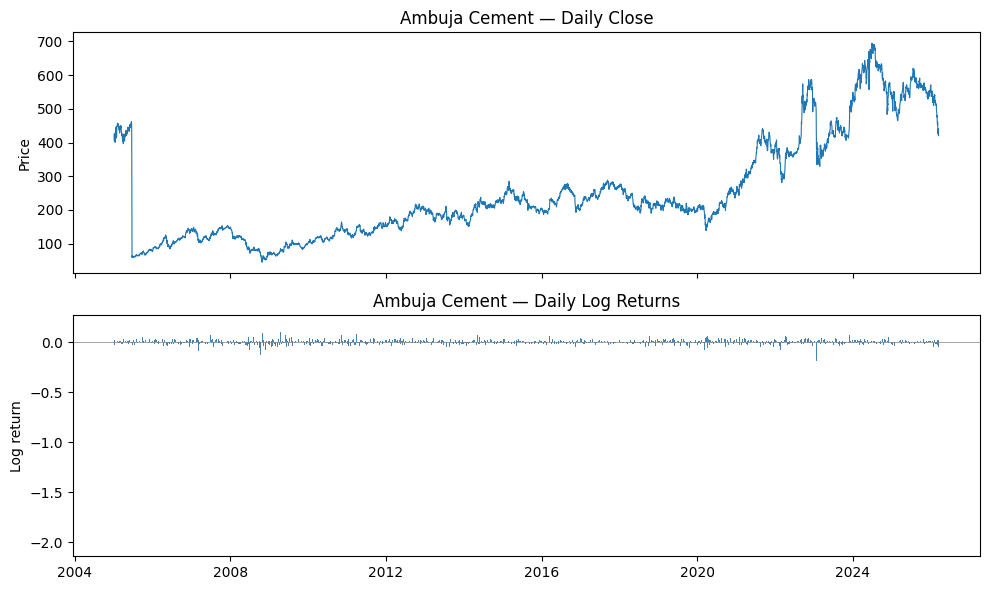

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(close, linewidth=0.8)
axes[0].set_ylabel("Price")
axes[0].set_title("Ambuja Cement — Daily Close")

axes[1].bar(
    log_returns.index,
    log_returns.values,
    width=2,
    color="steelblue",
)
axes[1].set_ylabel("Log return")
axes[1].set_title("Ambuja Cement — Daily Log Returns")
axes[1].axhline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

### Checkpoint

> 🔍 Before the check runs, study the plot: do you see stretches where
> the return bars are consistently **tall** (turbulent) next to stretches
> where they are **short** (calm)? That alternating texture *is*
> volatility clustering.

In [32]:
# Visual checkpoint — no assertion needed for plots.
# Verify the objects exist and have the right structure.
assert len(log_returns) > 50, (
    f"Only {len(log_returns)} returns — expected at least 50 "
    f"for a meaningful visualization."
)
print(
    "Checkpoint passed. Inspect the plots above: "
    "do you see periods where returns cluster together "
    "(large moves followed by large moves)?"
)

Checkpoint passed. Inspect the plots above: do you see periods where returns cluster together (large moves followed by large moves)?


> ✅ The Checkpoint just confirms there are enough observations (>50) for
> the visualization to be meaningful. The real payoff is your eyes
> registering the clustering.

➡️ Let's quantify the distribution of returns next.

## 6. Summarize return statistics

### Problem

Before modeling, quantify the basic properties of the return series.
Mean, standard deviation, **skewness**, and **kurtosis** tell you whether
the data is roughly symmetric and how heavy the tails are. Financial
returns famously have **excess kurtosis** — heavier tails than a normal
distribution — which further motivates GARCH-type models.

### Approach

Use `describe()` for the basics, then compute skew and excess kurtosis
separately:

-   `log_returns.describe()` — count, mean, std, min, quartiles, max.
-   `log_returns.skew()` — asymmetry.
-   `log_returns.kurtosis()` — excess kurtosis (0 for a normal
    distribution in pandas' convention).

### Tasks

Print the descriptive statistics for `log_returns`.

**Code 8.1.6.1**:

In [ ]:
log_returns.describe()

Compute and print the skewness and excess kurtosis. A kurtosis above zero
means heavier tails than a normal distribution.

**Code Task 8.1.6.2**:

In [33]:
# Calculate skewness and excess kurtosis using pandas built-in methods
skew = log_returns.skew()
kurt = log_returns.kurt()  # pandas computes excess kurtosis by default (Normal = 0)

print(f"Skewness:       {skew:.4f}")
print(f"Excess kurtosis: {kurt:.4f}")

Skewness:       -36.9129
Excess kurtosis: 2127.4164


### Checkpoint

In [34]:
assert isinstance(skew, float), (
    f"Expected skew to be a float, got {type(skew).__name__}."
)
assert isinstance(kurt, float), (
    f"Expected kurt to be a float, got {type(kurt).__name__}."
)
print(
    f"Checkpoint passed. "
    f"Skewness={skew:.4f}, Excess kurtosis={kurt:.4f}. "
    f"Kurtosis > 0 suggests heavy tails."
)

Checkpoint passed. Skewness=-36.9129, Excess kurtosis=2127.4164. Kurtosis > 0 suggests heavy tails.


> 📊 How to read these two numbers
>
> - **Skewness** near 0 ⇒ roughly symmetric returns; negative skew
>   (common in equities) ⇒ crashes are sharper than rallies.
> - **Excess kurtosis > 0** ⇒ **fat tails**: extreme days happen far more
>   often than a normal distribution predicts. This is *why* a Gaussian
>   constant-variance model under-states risk — and a recurring theme
>   into Lesson 3.

➡️ Finally, let's make the time-varying volatility explicit with a
rolling measure.

## 7. Visualize volatility clustering with a rolling standard deviation

### Problem

The return bar chart hints at clustering, but a **rolling standard
deviation** makes it explicit. This rolling measure is a simple proxy for
time-varying volatility and gives direct visual evidence that a
constant-variance assumption is wrong for this data.

### Approach

Compute a rolling std of `log_returns` over a **21-trading-day** window
(≈ one calendar month) and plot it beneath the return series:

-   `log_returns.rolling(window).std()` — rolling-window standard
    deviation.

### Tasks

Compute the 21-day rolling standard deviation and plot it.

**Code Task 8.1.7.1**:

In [ ]:
import matplotlib.pyplot as plt

# Calculate the rolling standard deviation using a 21-day trading window
rolling_vol = log_returns.rolling(window=21).std()

# Your exact plotting code structure
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# Top plot: Raw Daily Log Returns
axes[0].bar(
    log_returns.index,
    log_returns.values,
    width=2,
    color="steelblue",
)
axes[0].set_ylabel("Log return")
axes[0].set_title("Daily Log Returns")
axes[0].axhline(0, color="gray", linewidth=0.5)

# Bottom plot: Dynamic 21-Day Rolling Volatility
axes[1].plot(rolling_vol, color="darkorange", linewidth=1)
axes[1].set_ylabel("Rolling std (21d)")
axes[1].set_title("21-Day Rolling Volatility")

plt.tight_layout()
plt.show()

### Checkpoint

> 🔍 The bottom panel is a *direct picture of volatility over time*. Where
> it rises, returns are swinging widely; where it dips, the market is
> calm. A constant-variance model would replace this whole wandering line
> with one flat level — clearly a poor fit.

In [38]:
assert rolling_vol is not None, "rolling_vol was not created."
# The first 20 values should be NaN (window=21 needs 21 points)
n_nan = rolling_vol.isna().sum()
assert n_nan == 20, (
    f"Expected 20 NaN values at the start of rolling_vol, "
    f"got {n_nan}. Check your window size."
)
print(
    f"Checkpoint passed. "
    f"Rolling volatility has {len(rolling_vol)} values "
    f"({n_nan} leading NaNs from the 21-day window). "
    f"Max rolling vol: {rolling_vol.max():.6f}, "
    f"min: {rolling_vol.min():.6f}."
)

AssertionError: Expected 20 NaN values at the start of rolling_vol, got 0. Check your window size.

> ✅ The Checkpoint confirms the rolling series exists and has exactly
> **20 leading `NaN`s** (a 21-day window needs 21 points before it can
> produce its first value). The reported max-vs-min rolling volatility
> quantifies just how much the spread changes — the gap between them is
> the clustering, measured.

# Wrap-up

In this notebook you:

-   **Fetched** daily stock price data from a web API (simulated with a
    local mock), parsed the JSON response, and saved it as a CSV file.
-   **Loaded** that CSV into a properly indexed pandas DataFrame.
-   **Computed** log returns from the closing-price series and verified
    there were no missing or infinite values.
-   **Visualized** the price and return series to catch data-quality
    issues and observe volatility patterns.
-   **Summarized** the returns with skewness and excess kurtosis,
    confirming heavier-than-normal tails.
-   **Plotted** a rolling standard deviation to make volatility
    clustering visually explicit.

> 🧠 The one idea to carry forward: a single volatility number hides the
> truth. Risk **clusters and changes over time**, so the model we build
> in Lesson 3 must let the variance itself evolve.

➡️ **Next**, you will apply **test-driven development** to write unit
tests that validate your data loading and return computations — making
the pipeline robust *before* you start modeling.

> 📌 **A note on return types going forward.** Here you used **log
> returns** (additive, convenient for exploration). Starting in Lesson 2,
> the project switches to **simple percentage returns**
> (`pct_change() * 100`): more interpretable (a value of `2.0` means a 2%
> rise), and a natural fit for the `arch` library's GARCH implementation.
> For the small daily moves typical of equities the two definitions are
> nearly identical, so every intuition you built here still applies.